In [30]:
from transformers import GPT2LMHeadModel

In [31]:
model = GPT2LMHeadModel.from_pretrained("gpt2")

sd_hf = model.state_dict()

# for k,v in sd_hf.items():
#     print(k,v.shape)


sd_hf["transformer.h.0.attn.c_attn.bias"].view(-1)

tensor([ 0.4803, -0.5254, -0.4293,  ...,  0.0126, -0.0499,  0.0032])

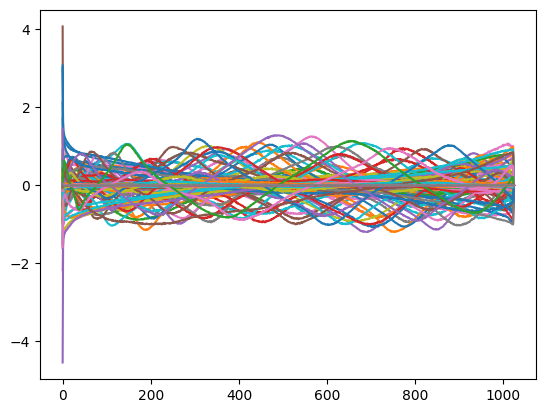

In [32]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(sd_hf["transformer.wpe.weight"])

(<matplotlib.image.AxesImage at 0x162f96490>,
 <matplotlib.image.AxesImage at 0x162f83130>)

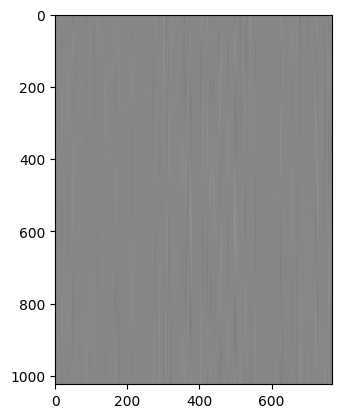

In [33]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"]),plt.imshow(sd_hf["transformer.wpe.weight"],cmap = "gray")

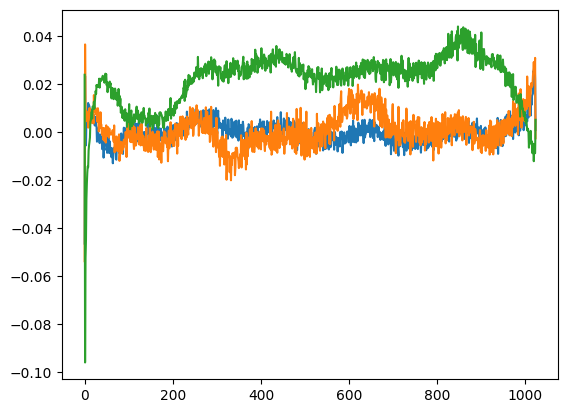

In [34]:
plt.plot(sd_hf["transformer.wpe.weight"][:,150])
plt.plot(sd_hf["transformer.wpe.weight"][:,200])
plt.plot(sd_hf["transformer.wpe.weight"][:,250])

In [37]:
with open('input.txt','r') as f:
    text = f.read()
data = text[:1000]


In [38]:
# inference for hugging face


from transformers import pipeline, set_seed
generator = pipeline('text-generation',model='gpt2')
set_seed(42)

generator("Hello how are you",max_length=30,num_return_sequences=42)

Device set to use mps:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello how are you doing?\n\nYeah, I'm working on my third full-length album, I feel like I'm really ready for it to be on my hands. So I'm doing new material and I'm really excited about it.\n\nSo what's your current state of mind?\n\nI'm still in the stage and I'm working on it, but I'm also working on the next release. I'm working on it right now, where I'm working on it with the writers, who are all over the world. So you know, I'm still working on it.\n\nWhy did you decide to do it?\n\nWell, I wanted to do a new album, but I didn't want to do it in the same way that I did the first. I didn't want to do something that I was doing in a different way.\n\nI've heard a lot of great things about you, you know?\n\nYeah! I've heard a lot of great things about myself, but I'm not a huge fan of people like these, and I think people are really just looking for a different kind of person. I'm just trying to put this album together as I can, so that hopefully I can get it o

In [36]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

NameError: name 'data' is not defined